# Example application of the Kalman filter to a PTA-GW system

This notebook demonstrates the application of the Kalman filter to a PTA perturbed by a continuous GW, as described in e.g. https://arxiv.org/abs/2409.14613 and https://arxiv.org/abs/2410.10087

---

# 1. Creating synthetic data <a name="synthetic"></a>



In [55]:
import numpy as np 
import matplotlib.pyplot as plt 
import scienceplots
import sdeint 
import pandas as pd 
plt.style.use('science')

class PTA_data:
    """ Simulates the signal from a PTA system perturbed by a continuous GW.
    """
    
    def __init__(self,γ,σp,σm, seed):

        #Path to data file
        pulsars = pd.read_csv("../data/NANOGrav_pulsars.csv")

        #Extract the parameters
        self.f         = pulsars["F0"].to_numpy()
    
        # User defined pulsar parameters
        #Map scalars to vector, so all pulsars have the same parameters
        self.γ = np.ones_like(self.f) * γ
        self.σp = np.ones_like(self.f) * σp


        self.σm = σm
        self.generator = np.random.default_rng(seed)
        



    def integrate(self,dt,n_steps):

        def f(x,t):
            A = -np.diag(self.γ)
            return A.dot(x)

        def h(x,t):
            return np.diag(self.σp)


        self.dt = dt
        self.n_steps      = n_steps
        print(f'Integrating for {self.n_steps*self.dt} seconds or {self.n_steps*self.dt / (365*24*3600)} years')
        self.t            = np.arange(0,self.n_steps*self.dt,self.dt)
 
        initial_conditions = np.zeros_like(self.f) #f' can be set =0 for all pulsars without loss of generality


        self.states = sdeint.itoint(f, h, initial_conditions, self.t,generator=self.generator)


        self.observation_no_noise,self.observation = self.measurement_process(self.states)
        


    def measurement_process(self,states):
        observation_no_noise = np.sin(states)
        observation = observation_no_noise + self.generator.normal(0, self.σm,size=observation_no_noise.shape) 
        return observation_no_noise,observation


    def plot_timeseries(self,psr_idx=1):
        """
        A plotting function which plots the states/observations as a function of time
        """


        #Setup the figure
        h,w =8,8
        rows = 2
        cols = 1
        fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(h,w),sharex=True)

    
        #Plot the states
        
        axes[0].plot(self.t,self.states[:,psr_idx]) 


        #Plot the measurements, without noise
        axes[1].plot(self.t,self.observation_no_noise[:,psr_idx],label='truth',c='C2')

        #Plot the measurements, with noise
        axes[1].scatter(self.t,self.observation[:,psr_idx],marker='x',label='data',c='C0')



        #Clean up axes
        fs=20
        axes[1].set_xlabel('t', fontsize=fs)

        axes[0].set_ylabel(r'$f_p$', fontsize=fs)
        axes[1].set_ylabel(r'$f_m$', fontsize=fs)

        plt.subplots_adjust(hspace=0.0)

        for ax in axes:
            ax.xaxis.set_tick_params(labelsize=fs-4)
            ax.yaxis.set_tick_params(labelsize=fs-4)

        axes[1].legend(prop={'size':fs})

        axes[0].set_title(f'Frequency timeseries for pulsar {psr_idx}')


Lets take a quick look at the data

Integrating for 5.0 seconds or 1.5854895991882294e-07 years


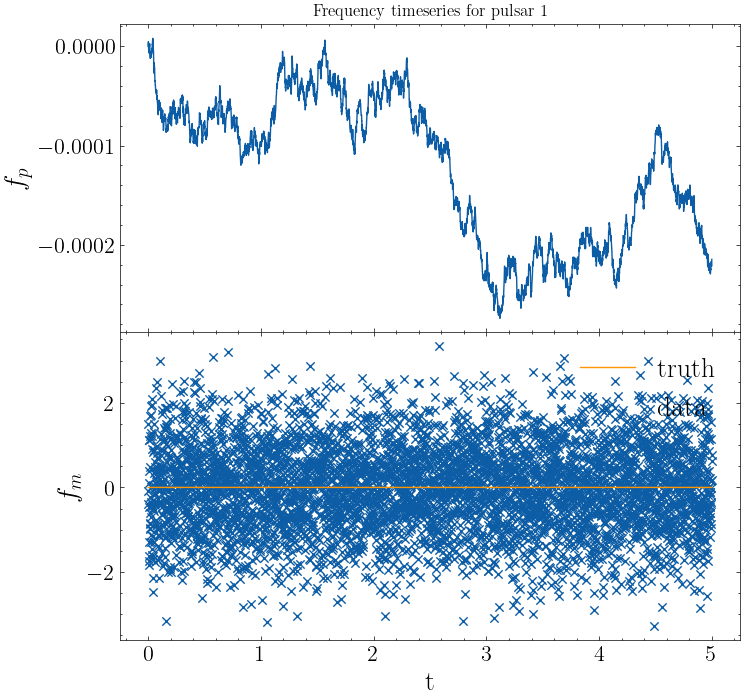

In [56]:
γ = 1e-13
σp   = 1e-4
σm   = 1.0
seed = 1

#Initialise the class
PTA = PTA_data(γ=γ,σp=σp,σm=σm,seed=seed)

#Integrate
PTA.integrate(dt=0.001,n_steps=5000)

# #Plot
PTA.plot_timeseries()

## 4. Running the UKF 

We can also use the unscented Kalman filter (UKF) on the same data.

We now need to specify some additional tuning parameters of the UKF, $\alpha$, $\beta$ and $\gamma$

The log-likelihood is 4382.278986956469


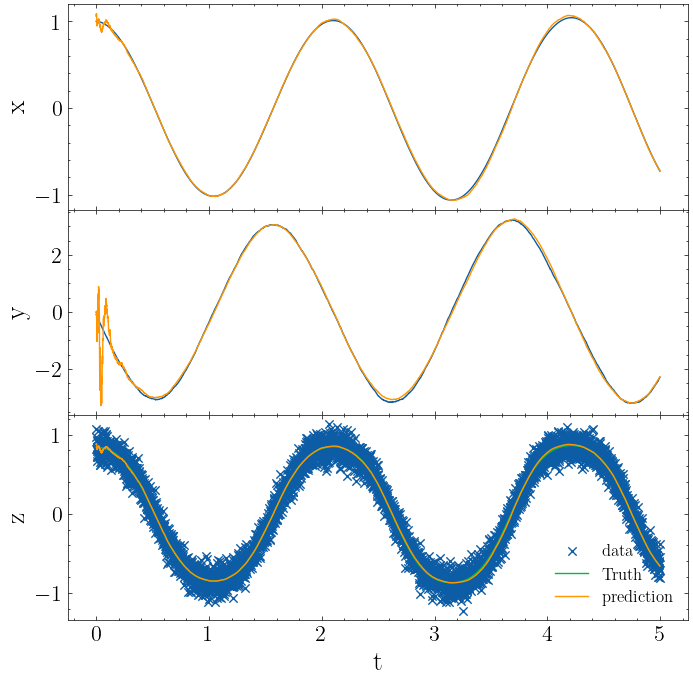

In [37]:
from kalman_filter import UnscentedKalmanFilter
from model import UKFKalmanPendulum

α  =1e-4 
β = 2 
κ = 0

model = UKFKalmanPendulum(dt=dt) # a UKF specific model of the double pendulum 
UKF      = UnscentedKalmanFilter(model,data,x_guess,P0,α,β,κ)
UKF.run(parameters_dict.sample())
Pendulum.plot_timeseries(plot_true_state=True, prediction_data=[UKF.state_predictions,UKF.measurement_predictions])
print(f'The log-likelihood is {UKF.ll}')

## 5. Erroneous parameters 

We have so far given the filter the true injection parameters used to generate the underlying synthetic data.

What happens if we give it the wrong parameters? 

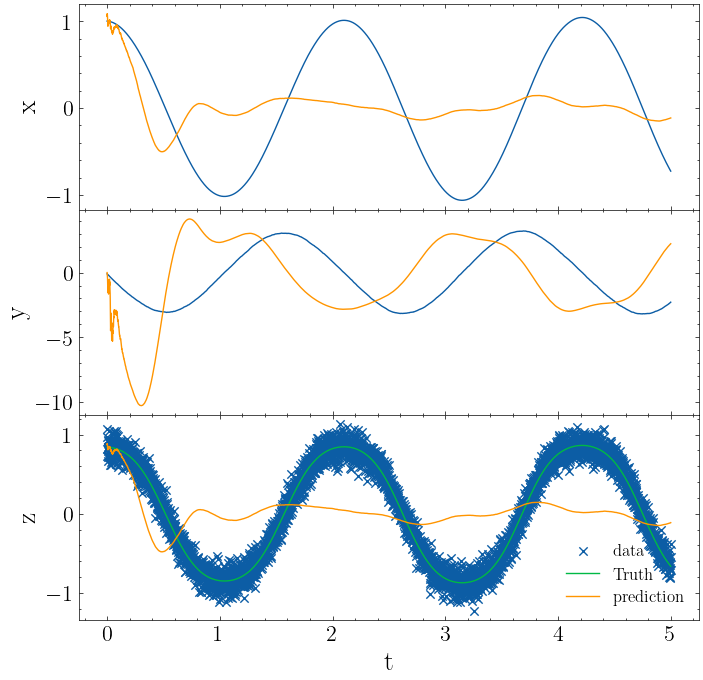

In [38]:
selected_parameters = parameters_dict.sample()
selected_parameters['g'] = 100.0 # make gravity 100 times stronger 
#Run the filter
KF.run(selected_parameters)

#Plot the results 
Pendulum.plot_timeseries(plot_true_state=True, prediction_data=[KF.state_predictions,KF.measurement_predictions])

As expected the filter now performs poorly. The problem of estimating the free parameters of the system can be solved by tuning the filter using likelihood inference methods (e.g. MCMC, expectation maximisation), or else by including the parameters in the states themselves.  

## 6. Tracking the parameters

So far we have set $\delta$-function priors on the free parameters of the model. That is, we assume them to be known exactly _a priori_. The parameters can be estimated by maximising the likelihood using e.g. nested sampling.

In this section we trial an alternative approach where the parameters are included as states. 

Specifically we extend our state vector to be $x = (x_1,x_2,g)$ and try to estimate $g$.


The log-likelihood is 4373.346209005856


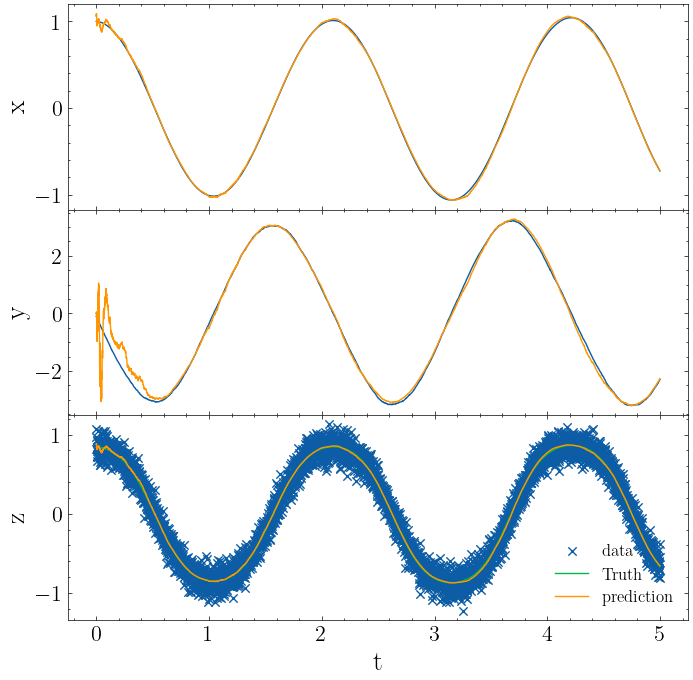

In [39]:
from kalman_filter import UnscentedKalmanFilter
from model import UKFKalmanPendulumEstimateG



#Generate some data 

g    = 10.0
σp   = 0.1
σm   = 0.1
x0   = 1.0
y0   = -0.1
seed = 1
dt   = 0.001

#Initialise the class
Pendulum = NoisyPendulum(g,σp,σm, x0, y0,seed)

#Integrate
Pendulum.integrate(dt=dt,n_steps=5000)


#Define the mathematical model
model = UKFKalmanPendulumEstimateG(dt=dt)


#Setup the filter
x_guess = np.array(([0,0,0]))      # guess of the initial states
P0      = 10*np.eye(3)             # uncertainty in that guess
data    = Pendulum.results[:,3].reshape(len(Pendulum.results),1)  # data to be ingested by the filter. Here reshaped to be a 2d array which the KF expects



#Run the filter 
α  =1e-4 
β = 2 
κ = 0
UKF      = UnscentedKalmanFilter(model,data,x_guess,P0,α,β,κ)
UKF.run(parameters_dict.sample())
Pendulum.plot_timeseries(plot_true_state=True, prediction_data=[UKF.state_predictions,UKF.measurement_predictions])
print(f'The log-likelihood is {UKF.ll}')



Good news - the filter still works even though we haven't told it what the value of $g$ is! 

Lets quickly plot the KF estimate of $g$ 

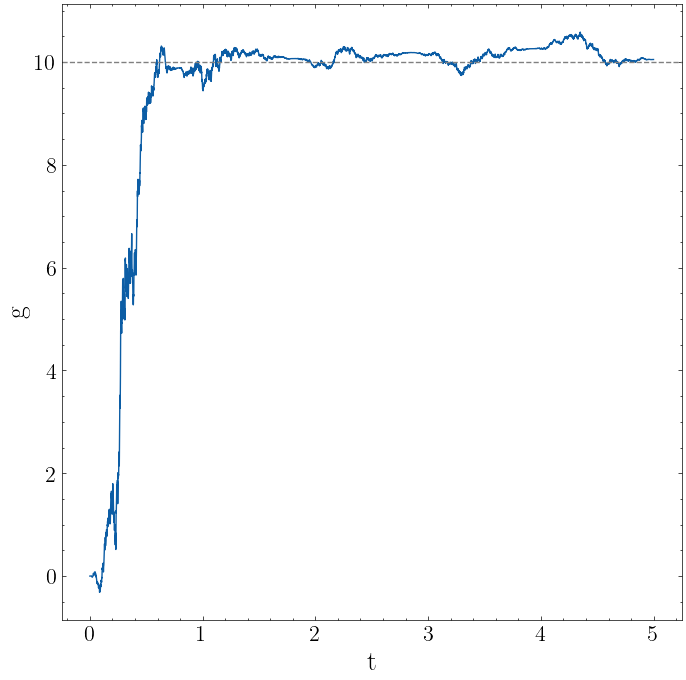

In [40]:
plt.figure(figsize=(8,8))
plt.plot(Pendulum.t,UKF.state_predictions[:,2])
plt.axhline(g,linestyle='--', c='0.5')


fs=20
plt.xlabel('t', fontsize=fs)
plt.ylabel('g', fontsize=fs)
plt.tick_params(labelsize=fs-4)